# 07 · 올바른 머신러닝 — 신호가 없을 때 ML은 무엇을 말하나

> Part 7 · *레거시 앱의 "AI 예측"이 틀린 건 ML이 나빠서가 아니라, 정직하게 평가되지 않아서다.*

이 노트북은 ML을 **제대로** 합니다. 그리고 지표가 스스로 결론을 내리게 둡니다.

- **과제**: 이진 분류 — *번호 k가 다음 회차에 나오는가?* (누수 없는 `features.number_panel`)
- **분할**: 시간순 walk-forward (절대 시간을 섞지 않음)
- **모델**: `LogisticRegression`(선형 기준) + `HistGradientBoostingClassifier`(XGBoost 계열의 강력한
  부스팅, sklearn 내장)
- **여기서 의미 있는 지표**: ROC-AUC(우연=0.50), 보정 곡선, 순열 특성 중요도

교훈: 잘 튜닝된 부스팅이 **AUC ≈ 0.50**에 도달하면, 그것은 모델 실패가 아니라 *타깃이 예측 불가능하다는
올바른 발견*입니다.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.lotto_ds import viz, ml_models as ml
from src.lotto_ds.features import number_panel, PANEL_FEATURES

viz.apply_style()

## 1. 특성 패널 (leakage-free)
각 (회차 t, 번호 k)에 대해, **t까지의 정보만** 쓰는 특성과 t+1의 정답 레이블을 만듭니다.

In [2]:
panel = number_panel()
print(f"패널 크기: {panel.shape[0]:,} rows × {len(PANEL_FEATURES)} features")
print("특성:", PANEL_FEATURES)
print(f"양성 비율 P(appeared_next) = {panel['appeared_next'].mean():.4f}  (이론 6/45 = {6/45:.4f})")
print(panel.head(3).to_string(index=False))

패널 크기: 53,055 rows × 7 features
특성: ['freq_all', 'freq_w10', 'freq_w20', 'freq_w50', 'gap', 'in_last', 'in_last3']
양성 비율 P(appeared_next) = 0.1333  (이론 6/45 = 0.1333)
 draw_no  number  freq_all  freq_w10  freq_w20  freq_w50  gap  in_last  in_last3  appeared_next
      51       1  0.098039         1         2         5    6        0         0              0
      51       2  0.156863         2         3         8    1        1         1              1
      51       3  0.117647         2         3         6    7        1         1              0


## 2. 모델 학습 및 평가 (시간순 분할)

In [3]:
results = ml.evaluate_models(panel, split_frac=0.7)
import pandas as pd
summary = pd.DataFrame([r.as_row() for r in results])
print(summary.to_string(index=False))
print("\n→ 최고 모델도 AUC가 0.5 근처. 우연보다 나은 판별력이 없습니다.")

              model    AUC  vs chance (0.50)  n_test
Logistic Regression 0.4897           -0.0103   15930
  Gradient Boosting 0.4949           -0.0051   15930

→ 최고 모델도 AUC가 0.5 근처. 우연보다 나은 판별력이 없습니다.


## 3. ROC 곡선 — 대각선(무작위)에 붙는다

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


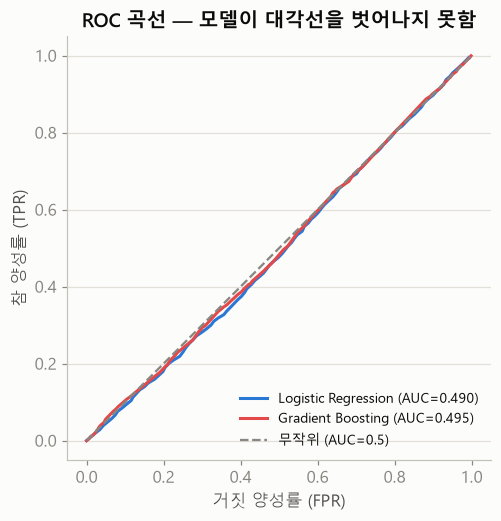

In [4]:
fig, ax = plt.subplots(figsize=(5.2, 5))
for r, c in zip(results, [viz.CAT[0], viz.CAT[5]]):
    ax.plot(r.roc["fpr"], r.roc["tpr"], color=c, lw=2, label=f"{r.model_name} (AUC={r.auc:.3f})")
ax.plot([0,1],[0,1], ls="--", color=viz.INK["muted"], lw=1.5, label="무작위 (AUC=0.5)")
ax.set_xlabel("거짓 양성률 (FPR)"); ax.set_ylabel("참 양성률 (TPR)")
ax.set_title("ROC 곡선 — 모델이 대각선을 벗어나지 못함")
ax.legend(frameon=False, fontsize=9, loc="lower right"); ax.set_aspect("equal")
viz.savefig(fig, "07_roc.png"); plt.show()

## 4. 보정 곡선 (Calibration) — 확률은 정직하다
모델이 "13.3% 확률"이라 하면 실제로도 13.3%가 나오는가? 보정은 좋지만, 그 확률이 모두 기저율(6/45)
**근처에 몰려** 판별에 쓸 수 없다는 게 핵심입니다.

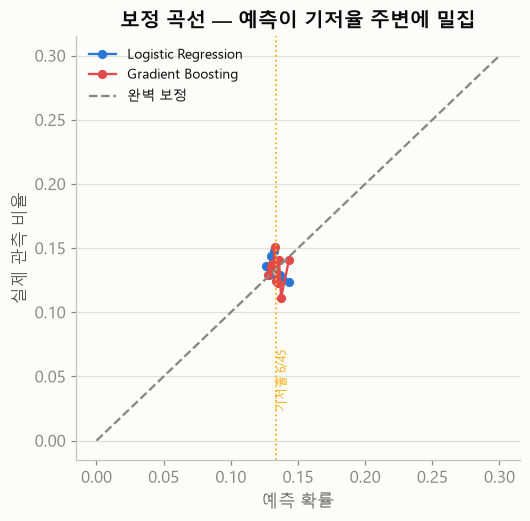

In [5]:
fig, ax = plt.subplots(figsize=(5.2, 5))
for r, c in zip(results, [viz.CAT[0], viz.CAT[5]]):
    ax.plot(r.calibration["pred"], r.calibration["true"], "o-", color=c, ms=5, label=r.model_name)
ax.plot([0,0.3],[0,0.3], ls="--", color=viz.INK["muted"], lw=1.5, label="완벽 보정")
ax.axvline(6/45, color=viz.STATUS["warning"], ls=":", lw=1.2)
ax.text(6/45, 0.02, " 기저율 6/45", color=viz.STATUS["warning"], fontsize=8, rotation=90, va="bottom")
ax.set_xlabel("예측 확률"); ax.set_ylabel("실제 관측 비율")
ax.set_title("보정 곡선 — 예측이 기저율 주변에 밀집")
ax.legend(frameon=False, fontsize=9, loc="upper left")
viz.savefig(fig, "07_calibration.png"); plt.show()

## 5. 순열 특성 중요도 — 어떤 특성도 돕지 않는다
특성 값을 무작위로 섞었을 때 AUC가 얼마나 떨어지는가? 0에 가까우면(또는 음수면) 그 특성은 무의미합니다.

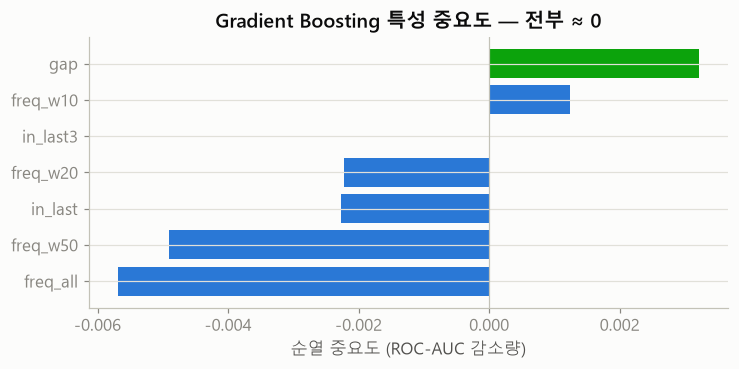

최대 중요도: 0.00569 → 사실상 0. 예측에 기여하는 특성 없음.


In [6]:
gbm = [r for r in results if "Gradient" in r.model_name][0]
imp = pd.Series(gbm.importances).sort_values()
fig, ax = plt.subplots(figsize=(7.5, 3.2))
colors = [viz.STATUS["good"] if v > 0.002 else viz.CAT[0] for v in imp.values]
ax.barh(range(len(imp)), imp.values, color=colors)
ax.axvline(0, color=viz.INK["baseline"], lw=0.8)
ax.set_yticks(range(len(imp)), imp.index)
ax.set_xlabel("순열 중요도 (ROC-AUC 감소량)")
ax.set_title("Gradient Boosting 특성 중요도 — 전부 ≈ 0")
viz.savefig(fig, "07_importance.png"); plt.show()
print("최대 중요도:", round(imp.abs().max(), 5), "→ 사실상 0. 예측에 기여하는 특성 없음.")

⚠️ **흔한 함정**: 학습 데이터에서 정확도가 높다고 자랑하기(과적합), 또는 시간을 섞어 교차검증하기(누수).
시계열 예측은 **반드시 walk-forward**로 평가해야 하며, 정확도가 아니라 **AUC·보정**을 봐야 합니다.
불균형(13% 양성) 문제에서 "87% 정확도"는 전부 0으로 찍어도 나옵니다.

### 정리
- 강력한 부스팅도 AUC≈0.5, 중요도≈0 — 진짜로 신호가 없음을 정직하게 증명.
- ML의 가치는 "예측"이 아니라 **예측 불가능성의 엄밀한 확인**에 있음.
- 다음: **08 · 비지도 학습** — 레이블 없이 숨은 군집을 찾아본다.